<a href="https://colab.research.google.com/github/Reem-Hafez0/Transformer-Based-En-to-Ar-NMT/blob/main/Transformer_EN2AR_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English → Arabic Neural Machine Translation
Transformer built from scratch using PyTorch and trained on the Tatoeba EN-AR corpus.


In [ ]:
!pip install -q sacrebleu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.2 MB/s eta 0:00:00


In [ ]:
import math
import re
import time
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import sentencepiece as spm
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split

import sacrebleu

print("All libraries loaded.")


All libraries loaded.


## 1. Load Dataset


In [ ]:
CORPUS_ID = "ymoslem/Tatoeba-EN-AR"

raw = load_dataset(CORPUS_ID)
print(raw)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30852 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['English', 'Arabic'],
        num_rows: 30852
    })
})


## 2. Text Normalization




In [ ]:
import unicodedata

def clean_english(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s',.!?;:\-]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_arabic(text):
    text = text.strip()
    # strip harakat (diacritics)
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F]', '', text)
    # remove tatweel
    text = re.sub(r'\u0640', '', text)
    # unify alef forms
    text = re.sub(r'[إأآا]', 'ا', text)
    # unify ta marbuta
    text = re.sub(r'ة', 'ه', text)
    # unify ya / alef maqsura
    text = re.sub(r'[يى]', 'ي', text)
    # keep only Arabic script + basic punctuation
    text = re.sub(r'[^\u0600-\u06FF\s،؟!.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [ ]:
en_sentences, ar_sentences = [], []

for row in raw['train']:
    en_sentences.append(clean_english(row['English']))
    ar_sentences.append(clean_arabic(row['Arabic']))

print(f"Loaded {len(en_sentences):,} sentence pairs.")


Loaded 30,852 sentence pairs.


## 3. Deduplication and Shuffling


In [ ]:
# Use a dict for O(1) dedup while preserving insertion order (Python 3.7+)
pair_set = dict.fromkeys(zip(en_sentences, ar_sentences))

en_clean = [p[0] for p in pair_set]
ar_clean = [p[1] for p in pair_set]

print(f"Pairs before dedup : {len(en_sentences):,}")
print(f"Pairs after dedup  : {len(en_clean):,}")


Pairs before dedup : 30,852
Pairs after dedup  : 30,774


In [ ]:
# Reproducible shuffle
pairs = list(zip(en_clean, ar_clean))
random.seed(42)
random.shuffle(pairs)

en_all, ar_all = zip(*pairs)
en_all, ar_all = list(en_all), list(ar_all)


## 4. Train / Validation / Test Split  (80 / 10 / 10)


In [ ]:
import os
SAVE_DIR = '/content/drive/MyDrive/EN_AR_Transformer'
os.makedirs(SAVE_DIR, exist_ok=True)

splits_dict = {
    'train': [{'en': e, 'ar': a} for e, a in zip(en_train, ar_train)],
    'val':   [{'en': e, 'ar': a} for e, a in zip(en_val,   ar_val)],
    'test':  [{'en': e, 'ar': a} for e, a in zip(en_test,  ar_test)],
}
with open(f'{SAVE_DIR}/splits.json', 'w', encoding='utf-8') as fh:
    json.dump(splits_dict, fh, ensure_ascii=False, indent=2)
print("Splits saved.")

Splits saved.


In [ ]:
en_tv, en_test, ar_tv, ar_test = train_test_split(
    en_all, ar_all, test_size=0.10, random_state=42
)
en_train, en_val, ar_train, ar_val = train_test_split(
    en_tv, ar_tv, test_size=0.111, random_state=42
)

print(f"Train : {len(en_train):,}")
print(f"Val   : {len(en_val):,}")
print(f"Test  : {len(en_test):,}")

splits_dict = {
    'train': [{'en': e, 'ar': a} for e, a in zip(en_train, ar_train)],
    'val':   [{'en': e, 'ar': a} for e, a in zip(en_val,   ar_val)],
    'test':  [{'en': e, 'ar': a} for e, a in zip(en_test,  ar_test)],
}
with open(f'{SAVE_DIR}/splits.json', 'w', encoding='utf-8') as fh:
    json.dump(splits_dict, fh, ensure_ascii=False, indent=2)
print("Splits saved.")


Train : 24,621
Val   : 3,075
Test  : 3,078
Splits saved.


## 5. BPE Tokenization with SentencePiece


In [ ]:
# Write plain-text files that SentencePiece trainer expects
with open('/content/src_corpus.txt', 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(en_train))

with open('/content/tgt_corpus.txt', 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(ar_train))

_common = dict(
    vocab_size=4000,
    character_coverage=1.0,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='<unk>',
    bos_piece='<bos>', eos_piece='<eos>',
)

spm.SentencePieceTrainer.train(
    input='/content/src_corpus.txt',
    model_prefix=f'{SAVE_DIR}/spm_en',
    **_common
)

spm.SentencePieceTrainer.train(
    input='/content/tgt_corpus.txt',
    model_prefix=f'{SAVE_DIR}/spm_ar',
    **_common
)

print("BPE models trained and saved.")


BPE models trained and saved.


In [ ]:
tok_en = spm.SentencePieceProcessor()
tok_en.load(f'{SAVE_DIR}/spm_en.model')

tok_ar = spm.SentencePieceProcessor()
tok_ar.load(f'{SAVE_DIR}/spm_ar.model')

PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

# Quick sanity check
print("EN sample :", tok_en.encode(en_train[0]))
print("AR sample :", tok_ar.encode(ar_train[0]))


EN sample : [94, 466, 175, 126, 66, 922, 565, 3967]
AR sample : [185, 493, 502, 1740, 559, 3950]


In [ ]:
src_lens = [len(tok_en.encode(s)) for s in en_train[:3000]]
tgt_lens = [len(tok_ar.encode(s)) for s in ar_train[:3000]]

MAX_LEN = 50
print(f"Max sequence length set to {MAX_LEN}")


Max sequence length set to 50


## 6. Transformer Architecture



In [ ]:
class SinusoidalPositionEmbedding(nn.Module):
    """Adds fixed sinusoidal position signals to token embeddings."""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(p=dropout)

        # Build the (max_len, d_model) table once
        table = torch.zeros(max_len, d_model)
        pos   = torch.arange(0, max_len).unsqueeze(1).float()
        scale = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        table[:, 0::2] = torch.sin(pos * scale)
        table[:, 1::2] = torch.cos(pos * scale)
        self.register_buffer('table', table.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.table[:, :x.size(1), :])


In [ ]:
class MultiHeadAttention(nn.Module):
    """Scaled dot-product attention projected across h independent heads."""

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(p=dropout)

    def _reshape_to_heads(self, t):
        B, L, _ = t.size()
        return t.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def _scaled_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        return torch.matmul(weights, V), weights

    def forward(self, Q, K, V, mask=None):
        Q = self._reshape_to_heads(self.W_q(Q))
        K = self._reshape_to_heads(self.W_k(K))
        V = self._reshape_to_heads(self.W_v(V))

        out, w = self._scaled_attention(Q, K, V, mask)
        B, _, L, _ = out.size()
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.W_o(out), w


In [ ]:
class PositionwiseFFN(nn.Module):
    """Two-layer fully-connected network applied independently at each position."""

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x):
        return self.fc2(self.drop(torch.relu(self.fc1(x))))


class AddAndNorm(nn.Module):
    """Residual connection followed by layer normalisation."""

    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x, sublayer_out):
        return self.norm(x + self.drop(sublayer_out))


In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn       = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1     = AddAndNorm(d_model, dropout)
        self.norm2     = AddAndNorm(d_model, dropout)

    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x, attn_out)
        x = self.norm2(x, self.ffn(x))
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, dropout=0.1, max_len=5000):
        super().__init__()
        self.tok_emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb  = SinusoidalPositionEmbedding(d_model, max_len, dropout)
        self.blocks   = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.scale = math.sqrt(d_model)

    def forward(self, src, src_mask):
        x = self.pos_emb(self.tok_emb(src) * self.scale)
        for blk in self.blocks:
            x = blk(x, src_mask)
        return x


In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn        = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1      = AddAndNorm(d_model, dropout)
        self.norm2      = AddAndNorm(d_model, dropout)
        self.norm3      = AddAndNorm(d_model, dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        x  = self.norm1(x, self.self_attn(x, x, x, tgt_mask)[0])
        ca_out, ca_w = self.cross_attn(x, memory, memory, src_mask)
        x  = self.norm2(x, ca_out)
        x  = self.norm3(x, self.ffn(x))
        return x, ca_w


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, dropout=0.1, max_len=5000):
        super().__init__()
        self.tok_emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb  = SinusoidalPositionEmbedding(d_model, max_len, dropout)
        self.blocks   = nn.ModuleList(
            [DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.scale = math.sqrt(d_model)

    def forward(self, tgt, memory, src_mask, tgt_mask):
        x = self.pos_emb(self.tok_emb(tgt) * self.scale)
        cross_weights = []
        for blk in self.blocks:
            x, cw = blk(x, memory, src_mask, tgt_mask)
            cross_weights.append(cw)
        return x, cross_weights


In [ ]:
def build_src_mask(src):
    return (src != PAD_ID).unsqueeze(1).unsqueeze(2)

def build_tgt_mask(tgt):
    L        = tgt.size(1)
    pad_mask = (tgt != PAD_ID).unsqueeze(1).unsqueeze(2)
    causal   = torch.tril(torch.ones(L, L, device=tgt.device)).bool()
    return pad_mask & causal.unsqueeze(0).unsqueeze(0)


class Seq2SeqTransformer(nn.Module):
    """Full encoder-decoder Transformer for sequence-to-sequence translation."""

    def __init__(self, src_vocab, tgt_vocab,
                 d_model=128, num_heads=4, d_ff=512,
                 num_layers=3, dropout=0.2, max_len=5000):
        super().__init__()
        self.encoder = Encoder(src_vocab, d_model, num_heads, d_ff,
                               num_layers, dropout, max_len)
        self.decoder = Decoder(tgt_vocab, d_model, num_heads, d_ff,
                               num_layers, dropout, max_len)
        self.proj = nn.Linear(d_model, tgt_vocab)
        self._init_params()

    def _init_params(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt):
        memory = self.encoder(src, build_src_mask(src))
        dec_out, attn = self.decoder(tgt, memory,
                                     build_src_mask(src),
                                     build_tgt_mask(tgt))
        return self.proj(dec_out), attn


## 7. Model Instantiation


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Vocabulary sizes come from the trained BPE processors
SRC_VOCAB  = tok_en.get_piece_size()
TGT_VOCAB  = tok_ar.get_piece_size()

# Hyperparameters
D_MODEL    = 128
NUM_HEADS  = 4
D_FF       = 512
NUM_LAYERS = 3
DROPOUT    = 0.2

model = Seq2SeqTransformer(
    src_vocab  = SRC_VOCAB,
    tgt_vocab  = TGT_VOCAB,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    d_ff       = D_FF,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on : {DEVICE}")
print(f"Parameters: {n_params:,}")

# Forward-pass smoke test
_s = torch.randint(4, SRC_VOCAB, (2, 10)).to(DEVICE)
_t = torch.randint(4, TGT_VOCAB, (2, 8)).to(DEVICE)
_logits, _ = model(_s, _t)
print(f"Output shape: {_logits.shape}  ✓")


Model on : cuda
Parameters: 2,928,544
Output shape: torch.Size([2, 8, 4000])  ✓


## 8. Dataset and DataLoaders


In [ ]:
class ParallelCorpusDataset(Dataset):
    """Tokenizes and pads EN-AR sentence pairs on the fly."""

    def __init__(self, src_sents, tgt_sents, src_tok, tgt_tok, max_len=MAX_LEN):
        self.samples  = []
        n_dropped = 0
        for src_txt, tgt_txt in zip(src_sents, tgt_sents):
            src_ids = [BOS_ID] + src_tok.encode(src_txt) + [EOS_ID]
            tgt_ids = [BOS_ID] + tgt_tok.encode(tgt_txt) + [EOS_ID]
            if max(len(src_ids), len(tgt_ids)) > max_len:
                n_dropped += 1
                continue
            self.samples.append((src_ids, tgt_ids))
        if n_dropped:
            print(f"  Dropped {n_dropped} pairs exceeding max_len={max_len}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s, t = self.samples[idx]
        return torch.tensor(s, dtype=torch.long), torch.tensor(t, dtype=torch.long)


def pad_collate(batch):
    srcs, tgts = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_ID)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_ID)
    return src_pad, tgt_pad[:, :-1], tgt_pad[:, 1:]   # teacher-forcing split


In [ ]:
BATCH_SIZE = 64

ds_train = ParallelCorpusDataset(en_train, ar_train, tok_en, tok_ar)
ds_val   = ParallelCorpusDataset(en_val,   ar_val,   tok_en, tok_ar)
ds_test  = ParallelCorpusDataset(en_test,  ar_test,  tok_en, tok_ar)

_loader_kw = dict(collate_fn=pad_collate, pin_memory=True, num_workers=2)
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  **_loader_kw)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, **_loader_kw)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, **_loader_kw)

print(f"Batches — train: {len(loader_train)} | val: {len(loader_val)} | test: {len(loader_test)}")


  Dropped 89 pairs exceeding max_len=50
  Dropped 17 pairs exceeding max_len=50
  Dropped 9 pairs exceeding max_len=50
Batches — train: 384 | val: 48 | test: 48


## 9. Loss, Optimizer, and Learning-Rate Schedule


In [ ]:
class SmoothedCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing; ignores PAD positions."""

    def __init__(self, vocab_size, pad_idx=PAD_ID, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_idx    = pad_idx
        self.smoothing  = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits, targets):
        logits  = logits.view(-1, self.vocab_size)
        targets = targets.view(-1)

        with torch.no_grad():
            soft = torch.full_like(logits, self.smoothing / (self.vocab_size - 2))
            soft.scatter_(1, targets.unsqueeze(1), self.confidence)
            soft[:, self.pad_idx] = 0
            soft[targets == self.pad_idx] = 0

        log_p = torch.log_softmax(logits, dim=-1)
        loss  = -(soft * log_p).sum(dim=-1)
        n_tok = (targets != self.pad_idx).sum().float()
        return loss.sum() / n_tok.clamp(min=1)


criterion = SmoothedCrossEntropy(TGT_VOCAB, pad_idx=PAD_ID, smoothing=0.1)


In [ ]:
class TransformerLRSchedule:
    """Noam warmup schedule from 'Attention Is All You Need'."""

    def __init__(self, optimizer, d_model, warmup_steps=2000):
        self.opt   = optimizer
        self.d     = d_model
        self.warm  = warmup_steps
        self._t    = 0

    def step(self):
        self._t += 1
        lr = self._lr()
        for g in self.opt.param_groups:
            g['lr'] = lr
        return lr

    def _lr(self):
        t = self._t
        return (self.d ** -0.5) * min(t ** -0.5, t * self.warm ** -1.5)


optimizer = optim.Adam(
    model.parameters(), lr=0,
    betas=(0.9, 0.98), eps=1e-9, weight_decay=1e-4
)
lr_sched = TransformerLRSchedule(optimizer, d_model=D_MODEL, warmup_steps=2000)
scaler   = GradScaler()  # for AMP fp16 training


/tmp/ipykernel_2748/962997.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler   = GradScaler()  # for AMP fp16 training


## 10. Training Loop


In [ ]:
def run_train_epoch(model, loader, opt, sched, loss_fn, amp_scaler, device):
    model.train()
    total_loss = total_toks = 0

    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = (t.to(device) for t in (src, tgt_in, tgt_out))
        opt.zero_grad()

        with autocast():
            logits, _ = model(src, tgt_in)
            loss = loss_fn(logits, tgt_out)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        sched.step()
        amp_scaler.step(opt)
        amp_scaler.update()

        n = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n
        total_toks += n

    return total_loss / total_toks


@torch.no_grad()
def run_eval(model, loader, loss_fn, device):
    model.eval()
    total_loss = total_toks = 0

    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = (t.to(device) for t in (src, tgt_in, tgt_out))
        with autocast():
            logits, _ = model(src, tgt_in)
            loss = loss_fn(logits, tgt_out)
        n = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n
        total_toks += n

    return total_loss / total_toks


In [ ]:
NUM_EPOCHS   = 50
PATIENCE     = 10
CKPT_PATH    = f'{SAVE_DIR}/best_model.pt'

best_val     = float('inf')
stagnant     = 0
hist_train   = []
hist_val     = []

hdr = f"{'Epoch':>6} | {'TrainLoss':>9} | {'ValLoss':>8} | {'TrainPPL':>8} | {'ValPPL':>7} | {'LR':>10} | {'Sec':>5}"
print(hdr)
print('-' * len(hdr))

for ep in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss = run_train_epoch(model, loader_train, optimizer, lr_sched, criterion, scaler, DEVICE)
    vl_loss = run_eval(model, loader_val, criterion, DEVICE)

    hist_train.append(tr_loss)
    hist_val.append(vl_loss)

    tr_ppl = math.exp(min(tr_loss, 10))
    vl_ppl = math.exp(min(vl_loss, 10))
    lr_now = lr_sched._lr()
    elapsed = time.time() - t0

    print(f"{ep:>6} | {tr_loss:>9.4f} | {vl_loss:>8.4f} | {tr_ppl:>8.2f} | {vl_ppl:>7.2f} | {lr_now:>10.6f} | {elapsed:>4.1f}s")

    if vl_loss < best_val:
        best_val = vl_loss
        stagnant = 0
        torch.save({
            'epoch'      : ep,
            'state_dict' : model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_loss'   : vl_loss,
            'hist_train' : hist_train,
            'hist_val'   : hist_val,
        }, CKPT_PATH)
        print(f"  ✔ New best saved  (val_loss={vl_loss:.4f})")
    else:
        stagnant += 1
        print(f"  · No gain [{stagnant}/{PATIENCE}]")
        if stagnant >= PATIENCE:
            print(f"Early stopping triggered at epoch {ep}.")
            break

print(f"\nFinal best val_loss : {best_val:.4f}  |  PPL : {math.exp(best_val):.2f}")


 Epoch | TrainLoss |  ValLoss | TrainPPL |  ValPPL |         LR |   Sec
-----------------------------------------------------------------------


/tmp/ipykernel_2748/2440187891.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_2748/2440187891.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


     1 |    7.0459 |   6.0894 |  1148.17 |  441.15 |   0.000379 | 18.0s
  ✔ New best saved  (val_loss=6.0894)
     2 |    5.8209 |   5.5340 |   337.28 |  253.15 |   0.000759 | 16.4s
  ✔ New best saved  (val_loss=5.5340)
     3 |    5.3839 |   5.1746 |   217.87 |  176.73 |   0.001138 | 16.7s
  ✔ New best saved  (val_loss=5.1746)
     4 |    5.0478 |   4.8543 |   155.68 |  128.29 |   0.001518 | 15.5s
  ✔ New best saved  (val_loss=4.8543)
     5 |    4.7172 |   4.5694 |   111.85 |   96.49 |   0.001897 | 15.3s
  ✔ New best saved  (val_loss=4.5694)
     6 |    4.4036 |   4.3276 |    81.75 |   75.76 |   0.001841 | 15.6s
  ✔ New best saved  (val_loss=4.3276)
     7 |    4.0905 |   4.1324 |    59.77 |   62.33 |   0.001705 | 16.4s
  ✔ New best saved  (val_loss=4.1324)
     8 |    3.8753 |   4.0522 |    48.20 |   57.52 |   0.001595 | 15.6s
  ✔ New best saved  (val_loss=4.0522)
     9 |    3.7164 |   3.9674 |    41.12 |   52.85 |   0.001504 | 15.3s
  ✔ New best saved  (val_loss=3.9674)
    10 |  

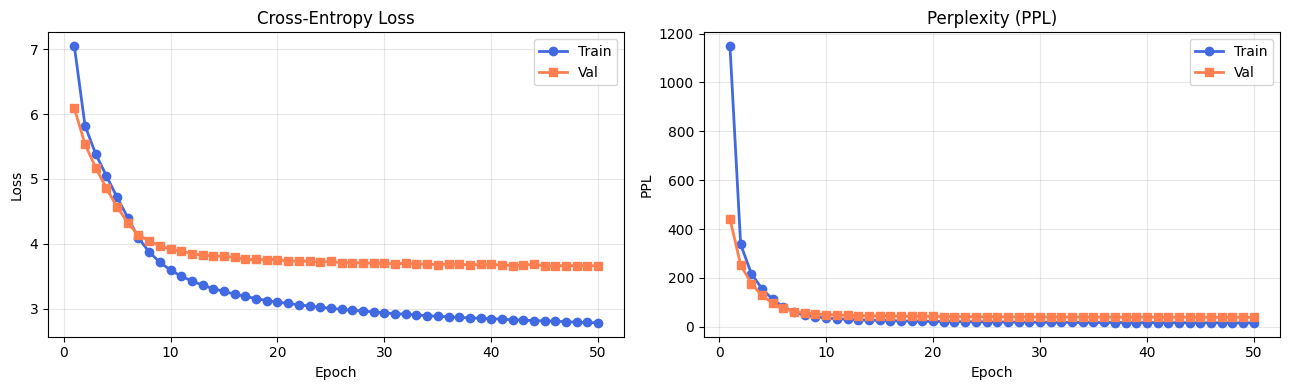

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep_range = range(1, len(hist_train) + 1)

ax1.plot(ep_range, hist_train, 'o-', color='royalblue',  lw=2, label='Train')
ax1.plot(ep_range, hist_val,   's-', color='coral',      lw=2, label='Val')
ax1.set(title='Cross-Entropy Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(alpha=0.3)

tr_ppl_hist = [math.exp(min(l, 10)) for l in hist_train]
vl_ppl_hist = [math.exp(min(l, 10)) for l in hist_val]

ax2.plot(ep_range, tr_ppl_hist, 'o-', color='royalblue', lw=2, label='Train')
ax2.plot(ep_range, vl_ppl_hist, 's-', color='coral',     lw=2, label='Val')
ax2.set(title='Perplexity (PPL)', xlabel='Epoch', ylabel='PPL')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/learning_curves.png', dpi=150)
plt.show()


In [ ]:
# Restore the best checkpoint for inference
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")


Loaded checkpoint from epoch 46  (val_loss=3.6593)


## 11. Inference — Greedy and Beam Search


In [ ]:
@torch.no_grad()
def translate_greedy(model, sentence, src_tok, tgt_tok, device, max_len=60):
    model.eval()
    ids = [BOS_ID] + src_tok.encode(clean_english(sentence)) + [EOS_ID]
    src = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    memory   = model.encoder(src, build_src_mask(src))
    out_ids  = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    for _ in range(max_len):
        dec_out, _ = model.decoder(out_ids, memory,
                                   build_src_mask(src),
                                   build_tgt_mask(out_ids))
        next_id = model.proj(dec_out[:, -1, :]).argmax(dim=-1).item()
        if next_id == EOS_ID:
            break
        out_ids = torch.cat([out_ids,
                             torch.tensor([[next_id]], device=device)], dim=1)
    return tgt_tok.decode(out_ids[0, 1:].tolist())


@torch.no_grad()
def translate_beam(model, sentence, src_tok, tgt_tok, device,
                   beam_size=4, max_len=60, length_penalty=0.7):
    model.eval()
    ids  = [BOS_ID] + src_tok.encode(clean_english(sentence)) + [EOS_ID]
    src  = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    memory   = model.encoder(src, build_src_mask(src))
    beams    = [(0.0, [BOS_ID], False)]   # (score, token_ids, is_done)
    finished = []

    for _ in range(max_len):
        expanded = []
        for score, toks, done in beams:
            if done:
                finished.append((score, toks))
                continue
            dec_in   = torch.tensor([toks], dtype=torch.long, device=device)
            dec_out, _ = model.decoder(dec_in, memory,
                                       build_src_mask(src),
                                       build_tgt_mask(dec_in))
            log_p = torch.log_softmax(model.proj(dec_out[:, -1, :]), dim=-1).squeeze(0)
            top_lp, top_id = log_p.topk(beam_size)
            for lp, tid in zip(top_lp.tolist(), top_id.tolist()):
                expanded.append((score + lp, toks + [tid], tid == EOS_ID))

        if not expanded:
            break
        expanded.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
        beams = expanded[:beam_size]
        if all(d for _, _, d in beams):
            break

    finished += [(s, t) for s, t, _ in beams]
    if not finished:
        return ""

    _, best_toks = max(finished, key=lambda x: x[0] / (len(x[1]) ** length_penalty))
    best_toks = [t for t in best_toks if t not in (BOS_ID, EOS_ID)]
    return tgt_tok.decode(best_toks)


In [ ]:
probe_sentences = [
    "How are you?",
    "Please help me.",
    "What time is it?",
    "I love you.",
    "Open the door.",
    "I am tired.",
    "She is late.",
    "Drink some water.",
    "He left early.",
    "I am hungry.",
    "Come with me.",
    "It is cold today.",
]

print(f"{'English':<45} | {'Arabic (beam)':^35}")
print('-' * 85)
for sent in probe_sentences:
    ar = translate_beam(model, sent, tok_en, tok_ar, DEVICE, beam_size=4)
    print(f"{sent:<45} | {ar}")


English                                       |            Arabic (beam)           
-------------------------------------------------------------------------------------
How are you?                                  | كيف حالك؟
Please help me.                               | من فضلك ساعدني.
What time is it?                              | متي الساعه؟
I love you.                                   | احبك.
Open the door.                                | افتح الباب.
I am tired.                                   | انا متعب.
She is late.                                  | انها متاخر.
Drink some water.                             | اشرب بعض الماء.
He left early.                                | غادر مبكرا.
I am hungry.                                  | انا جائع.
Come with me.                                 | تعال معي.
It is cold today.                             | الجو بارد اليوم.


## 12. Automatic Evaluation — BLEU

We report both character-level BLEU (more appropriate for morphologically rich Arabic) and standard word-level BLEU.


In [ ]:
@torch.no_grad()
def score_bleu(model, src_list, ref_list, src_tok, tgt_tok, device,
               beam_size=4, max_samples=None):
    pairs = list(zip(src_list, ref_list))
    if max_samples and len(pairs) > max_samples:
        pairs = random.sample(pairs, max_samples)

    print(f"Translating {len(pairs):,} pairs for BLEU...")
    preds, refs = [], []
    for i, (src_txt, ref_txt) in enumerate(pairs):
        preds.append(translate_beam(model, src_txt, src_tok, tgt_tok, device, beam_size))
        refs.append(ref_txt)
        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(pairs)}")

    bleu_char = sacrebleu.corpus_bleu(preds, [refs], tokenize='char')
    return bleu_char, preds, refs


bleu, hyps, refs = score_bleu(
    model, en_test, ar_test, tok_en, tok_ar, DEVICE,
    beam_size=4, max_samples=None
)

print(f"\n{'='*50}")
print(f"  Char-BLEU score : {bleu.score:.2f}")
print(f"  1-gram prec     : {bleu.precisions[0]:.2f}%")
print(f"  2-gram prec     : {bleu.precisions[1]:.2f}%")
print(f"  3-gram prec     : {bleu.precisions[2]:.2f}%")
print(f"  4-gram prec     : {bleu.precisions[3]:.2f}%")
print(f"  Brevity penalty : {bleu.bp:.4f}")
print(f"{'='*50}")


Translating 3,078 pairs for BLEU...
  200/3078
  400/3078
  600/3078
  800/3078
  1000/3078
  1200/3078
  1400/3078
  1600/3078
  1800/3078
  2000/3078
  2200/3078
  2400/3078
  2600/3078
  2800/3078
  3000/3078

  Char-BLEU score : 47.44
  1-gram prec     : 80.44%
  2-gram prec     : 58.64%
  3-gram prec     : 47.21%
  4-gram prec     : 39.39%
  Brevity penalty : 0.8717
